# Recommender Systems: Content-Based and Collaborative Filtering
## CSL7110 Assignment 3 - ML with Big Data


## Setup and Data Loading


In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.sparse.linalg import svds
from scipy.sparse import csr_matrix
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the MovieLens dataset
movies = pd.read_csv('ml-latest-small/movies.csv')
ratings = pd.read_csv('ml-latest-small/ratings.csv')
tags = pd.read_csv('ml-latest-small/tags.csv')

print("Dataset shapes:")
print(f"Movies: {movies.shape}")
print(f"Ratings: {ratings.shape}")
print(f"Tags: {tags.shape}")

print("\nMovies sample:")
display(movies.head())

print("\nRatings sample:")
display(ratings.head())

print("\nDataset Statistics:")
print(f"Number of users: {ratings['userId'].nunique()}")
print(f"Number of movies: {movies['movieId'].nunique()}")
print(f"Number of ratings: {len(ratings)}")
print(f"Rating range: {ratings['rating'].min()} - {ratings['rating'].max()}")
print(f"Average rating: {ratings['rating'].mean():.2f}")

Dataset shapes:
Movies: (9742, 3)
Ratings: (100836, 4)
Tags: (3683, 4)

Movies sample:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



Ratings sample:


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931



Dataset Statistics:
Number of users: 610
Number of movies: 9742
Number of ratings: 100836
Rating range: 0.5 - 5.0
Average rating: 3.50


---
# Part 1: Content-Based Filtering 

## Task 1: Implementing TF-IDF Based Recommendation

In this task, we build a content-based recommender system using TF-IDF on movie genres.


In [3]:
# Load dataset and extract movie descriptions (genres)
movies['genres_processed'] = movies['genres'].str.replace('|', ' ')
movies['genres_processed'] = movies['genres_processed'].replace('(no genres listed)', '')

print("Processed genres sample:")
print(movies[['title', 'genres', 'genres_processed']].head(10))

Processed genres sample:
                                title  \
0                    Toy Story (1995)   
1                      Jumanji (1995)   
2             Grumpier Old Men (1995)   
3            Waiting to Exhale (1995)   
4  Father of the Bride Part II (1995)   
5                         Heat (1995)   
6                      Sabrina (1995)   
7                 Tom and Huck (1995)   
8                 Sudden Death (1995)   
9                    GoldenEye (1995)   

                                        genres  \
0  Adventure|Animation|Children|Comedy|Fantasy   
1                   Adventure|Children|Fantasy   
2                               Comedy|Romance   
3                         Comedy|Drama|Romance   
4                                       Comedy   
5                        Action|Crime|Thriller   
6                               Comedy|Romance   
7                           Adventure|Children   
8                                       Action   
9                    Ac

In [4]:
# Compute TF-IDF vectors using TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(movies['genres_processed'])

print(f"TF-IDF Matrix shape: {tfidf_matrix.shape}")
print(f"Number of features (unique genres): {len(tfidf_vectorizer.get_feature_names_out())}")
print(f"Feature names: {tfidf_vectorizer.get_feature_names_out()}")

TF-IDF Matrix shape: (9742, 21)
Number of features (unique genres): 21
Feature names: ['action' 'adventure' 'animation' 'children' 'comedy' 'crime'
 'documentary' 'drama' 'fantasy' 'fi' 'film' 'horror' 'imax' 'musical'
 'mystery' 'noir' 'romance' 'sci' 'thriller' 'war' 'western']


In [5]:
# Compute cosine similarity between items
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print(f"Cosine similarity matrix shape: {cosine_sim.shape}")
title_to_idx = pd.Series(movies.index, index=movies['title']).drop_duplicates()

print(f"\nNumber of movies indexed: {len(title_to_idx)}")

Cosine similarity matrix shape: (9742, 9742)

Number of movies indexed: 9742


In [6]:
# Implement a Recommendation Function
def get_content_recommendations(title, cosine_sim=cosine_sim, top_n=5):
    
    # Check if movie exists
    if title not in title_to_idx:
        matches = movies[movies['title'].str.contains(title, case=False, na=False)]
        if len(matches) == 0:
            return f"Movie '{title}' not found in database"
        title = matches.iloc[0]['title']
        print(f"Using closest match: {title}")
    idx = title_to_idx[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]
    movie_indices = [i[0] for i in sim_scores]
    recommendations = movies.iloc[movie_indices][['title', 'genres']].copy()
    recommendations['similarity_score'] = [round(score, 4) for idx, score in sim_scores]
    
    return recommendations

print("Recommendation function created successfully!")

Recommendation function created successfully!


In [7]:
# Test the recommender with sample queries

test_movies = ['Toy Story (1995)', 'Matrix, The (1999)', 'Forrest Gump (1994)', 
               'Godfather, The (1972)', 'Jurassic Park (1993)']

for movie in test_movies:
    print(f"\n{'='*60}")
    print(f"Top 5 Recommendations for: {movie}")
    print(f"{'='*60}")
    movie_info = movies[movies['title'] == movie]
    if len(movie_info) > 0:
        print(f"Genres: {movie_info['genres'].values[0]}")
    
    recommendations = get_content_recommendations(movie, top_n=5)
    if isinstance(recommendations, str):
        print(recommendations)
    else:
        display(recommendations)


Top 5 Recommendations for: Toy Story (1995)
Genres: Adventure|Animation|Children|Comedy|Fantasy


,title,genres,similarity_score
1706,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,1.0
2355,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,1.0
2809,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.0
3000,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.0
3568,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,1.0



Top 5 Recommendations for: Matrix, The (1999)
Genres: Action|Sci-Fi|Thriller


,title,genres,similarity_score
68,Screamers (1995),Action|Sci-Fi|Thriller,1.0
144,Johnny Mnemonic (1995),Action|Sci-Fi|Thriller,1.0
296,Virtuosity (1995),Action|Sci-Fi|Thriller,1.0
336,Timecop (1994),Action|Sci-Fi|Thriller,1.0
474,Blade Runner (1982),Action|Sci-Fi|Thriller,1.0



Top 5 Recommendations for: Forrest Gump (1994)
Genres: Comedy|Drama|Romance|War


,title,genres,similarity_score
1730,Life Is Beautiful (La Vita è bella) (1997),Comedy|Drama|Romance|War,1.0000
2262,Train of Life (Train de vie) (1998),Comedy|Drama|Romance|War,1.0000
6296,"Tiger and the Snow, The (La tigre e la neve) (...",Comedy|Drama|Romance|War,1.0000
6624,I Served the King of England (Obsluhoval jsem ...,Comedy|Drama|Romance|War,1.0000
346,"Colonel Chabert, Le (1994)",Drama|Romance|War,0.9403



Top 5 Recommendations for: Godfather, The (1972)
Genres: Crime|Drama


,title,genres,similarity_score
29,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,Crime|Drama,1.0
33,Dead Man Walking (1995),Crime|Drama,1.0
86,"Hate (Haine, La) (1995)",Crime|Drama,1.0
102,"Young Poisoner's Handbook, The (1995)",Crime|Drama,1.0
211,Heavenly Creatures (1994),Crime|Drama,1.0



Top 5 Recommendations for: Jurassic Park (1993)
Genres: Action|Adventure|Sci-Fi|Thriller


,title,genres,similarity_score
615,Independence Day (a.k.a. ID4) (1996),Action|Adventure|Sci-Fi|Thriller,1.0
656,Escape from L.A. (1996),Action|Adventure|Sci-Fi|Thriller,1.0
856,"Abyss, The (1989)",Action|Adventure|Sci-Fi|Thriller,1.0
858,Escape from New York (1981),Action|Adventure|Sci-Fi|Thriller,1.0
1044,Star Trek: First Contact (1996),Action|Adventure|Sci-Fi|Thriller,1.0


---
## Task 2: User-Profile-Based Content Recommender

Building a content-based recommender that personalizes recommendations based on user preferences.


In [8]:
# Construct User Profiles
movie_id_to_idx = pd.Series(movies.index, index=movies['movieId'])

def build_user_profile(user_id, ratings_df, tfidf_matrix, movie_id_to_idx):
    user_ratings = ratings_df[ratings_df['userId'] == user_id]
    if len(user_ratings) == 0:
        return None
    profile = np.zeros(tfidf_matrix.shape[1])
    total_weight = 0
    
    for _, row in user_ratings.iterrows():
        movie_id = row['movieId']
        rating = row['rating']
        if movie_id in movie_id_to_idx.index:
            idx = movie_id_to_idx[movie_id]
            profile += rating * tfidf_matrix[idx].toarray().flatten()
            total_weight += rating
    if total_weight > 0:
        profile = profile / total_weight
    
    return profile
print("Building user profiles...")
user_ids = ratings['userId'].unique()
user_profiles = {}

for user_id in user_ids:
    profile = build_user_profile(user_id, ratings, tfidf_matrix, movie_id_to_idx)
    if profile is not None:
        user_profiles[user_id] = profile

print(f"Built profiles for {len(user_profiles)} users")
print(f"Profile dimension: {len(list(user_profiles.values())[0])}")

Building user profiles...
Built profiles for 610 users
Profile dimension: 21


In [9]:
#Compute User-Movie Similarity and Get Recommendations

def get_user_recommendations(user_id, user_profiles, tfidf_matrix, movies_df, 
                            ratings_df, top_n=10):
    if user_id not in user_profiles:
        return f"User {user_id} not found"
    
    user_profile = user_profiles[user_id].reshape(1, -1)
    similarities = cosine_similarity(user_profile, tfidf_matrix).flatten()
    rated_movies = set(ratings_df[ratings_df['userId'] == user_id]['movieId'])
    movie_scores = []
    for idx, sim in enumerate(similarities):
        movie_id = movies_df.iloc[idx]['movieId']
        if movie_id not in rated_movies:
            movie_scores.append((idx, sim))
    movie_scores = sorted(movie_scores, key=lambda x: x[1], reverse=True)[:top_n]
    recommendations = []
    for idx, sim in movie_scores:
        recommendations.append({
            'title': movies_df.iloc[idx]['title'],
            'genres': movies_df.iloc[idx]['genres'],
            'similarity_score': round(sim, 4)
        })
    
    return pd.DataFrame(recommendations)
print("Testing user-profile-based recommendations:")
for user_id in [1, 5, 10]:
    print(f"\n{'='*60}")
    print(f"Top 10 Recommendations for User {user_id}")
    print(f"{'='*60}")
    user_rated = ratings[ratings['userId'] == user_id].merge(movies, on='movieId')
    user_top = user_rated.nlargest(5, 'rating')[['title', 'genres', 'rating']]
    print("User's top-rated movies:")
    display(user_top)
    
    print("\nRecommendations:")
    recommendations = get_user_recommendations(user_id, user_profiles, tfidf_matrix, 
                                               movies, ratings, top_n=10)
    display(recommendations)

Testing user-profile-based recommendations:

Top 10 Recommendations for User 1
User's top-rated movies:


,title,genres,rating
3,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,5.0
4,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,5.0
6,Bottle Rocket (1996),Adventure|Comedy|Crime|Romance,5.0
8,Rob Roy (1995),Action|Drama|Romance|War,5.0
9,Canadian Bacon (1995),Comedy|War,5.0



Recommendations:


,title,genres,similarity_score
0,Dragonheart 2: A New Beginning (2000),Action|Adventure|Comedy|Drama|Fantasy|Thriller,0.7910
1,"Hunting Party, The (2007)",Action|Adventure|Comedy|Drama|Thriller,0.7736
2,Flashback (1990),Action|Adventure|Comedy|Crime|Drama,0.7731
3,The Great Train Robbery (1978),Action|Adventure|Comedy|Crime|Drama,0.7731
4,Charlie's Angels: Full Throttle (2003),Action|Adventure|Comedy|Crime|Thriller,0.7605
5,After the Sunset (2004),Action|Adventure|Comedy|Crime|Thriller,0.7605
6,"Diamond Arm, The (Brilliantovaya ruka) (1968)",Action|Adventure|Comedy|Crime|Thriller,0.7605
7,Machete (2010),Action|Adventure|Comedy|Crime|Thriller,0.7605
8,Maximum Ride (2016),Action|Adventure|Comedy|Fantasy|Sci-Fi|Thriller,0.7597
9,"Stunt Man, The (1980)",Action|Adventure|Comedy|Drama|Romance|Thriller,0.7540



Top 10 Recommendations for User 5
User's top-rated movies:


...

,title,genres,similarity_score
0,Out of Sight (1998),Comedy|Crime|Drama|Romance|Thriller,0.7868
1,Nurse Betty (2000),Comedy|Crime|Drama|Romance|Thriller,0.7868
2,Confessions of a Dangerous Mind (2002),Comedy|Crime|Drama|Romance|Thriller,0.7868
3,Band of Outsiders (Bande à part) (1964),Comedy|Crime|Drama|Romance,0.7582
4,"Green Butchers, The (Grønne slagtere, De) (2003)",Comedy|Crime|Drama|Romance,0.7582
5,"Edukators, The (Die Fetten Jahre sind vorbei) ...",Comedy|Crime|Drama|Romance,0.7582
6,Did You Hear About the Morgans? (2009),Comedy|Crime|Drama|Romance,0.7582
7,Focus (2015),Comedy|Crime|Drama|Romance,0.7582
8,Osmosis Jones (2001),Action|Animation|Comedy|Crime|Drama|Romance|Th...,0.7570
9,Freeway (1996),Comedy|Crime|Drama|Thriller,0.7401



Top 10 Recommendations for User 10
User's top-rated movies:


,title,genres,rating
42,Troy (2004),Action|Adventure|Drama|War,5.0
44,"Notebook, The (2004)",Drama|Romance,5.0
48,First Daughter (2004),Comedy|Romance,5.0
57,Batman Begins (2005),Action|Crime|IMAX,5.0
62,Casino Royale (2006),Action|Adventure|Thriller,5.0



Recommendations:


,title,genres,similarity_score
0,Waiting to Exhale (1995),Comedy|Drama|Romance,0.9298
1,"American President, The (1995)",Comedy|Drama|Romance,0.9298
2,Mighty Aphrodite (1995),Comedy|Drama|Romance,0.9298
3,"Postman, The (Postino, Il) (1994)",Comedy|Drama|Romance,0.9298
4,Beautiful Girls (1996),Comedy|Drama|Romance,0.9298
5,Something to Talk About (1995),Comedy|Drama|Romance,0.9298
6,Don Juan DeMarco (1995),Comedy|Drama|Romance,0.9298
7,Eat Drink Man Woman (Yin shi nan nu) (1994),Comedy|Drama|Romance,0.9298
8,Nobody's Fool (1994),Comedy|Drama|Romance,0.9298
9,"Corrina, Corrina (1994)",Comedy|Drama|Romance,0.9298


In [10]:
#Evaluate User-Profile-Based Recommendations with Precision@K and Recall@K

def evaluate_user_profile_recommendations(user_profiles, tfidf_matrix, movies_df, 
                                         ratings_df, k=10, threshold=4.0):
    train_ratings, test_ratings = train_test_split(
        ratings_df, test_size=0.2, random_state=42
    )
    train_user_profiles = {}
    for user_id in train_ratings['userId'].unique():
        profile = build_user_profile(user_id, train_ratings, tfidf_matrix, movie_id_to_idx)
        if profile is not None:
            train_user_profiles[user_id] = profile
    
    precisions = []
    recalls = []
    test_users = test_ratings['userId'].unique()
    
    for user_id in test_users[:100]:  # Evaluate on subset for efficiency
        if user_id not in train_user_profiles:
            continue
        user_test = test_ratings[test_ratings['userId'] == user_id]
        relevant_items = set(user_test[user_test['rating'] >= threshold]['movieId'])
        
        if len(relevant_items) == 0:
            continue
        user_profile = train_user_profiles[user_id].reshape(1, -1)
        similarities = cosine_similarity(user_profile, tfidf_matrix).flatten()
        train_movies = set(train_ratings[train_ratings['userId'] == user_id]['movieId'])
        movie_scores = []
        for idx, sim in enumerate(similarities):
            movie_id = movies_df.iloc[idx]['movieId']
            if movie_id not in train_movies:
                movie_scores.append((movie_id, sim))
        
        movie_scores = sorted(movie_scores, key=lambda x: x[1], reverse=True)[:k]
        recommended_items = set([m[0] for m in movie_scores])
        hits = len(recommended_items & relevant_items)
        precision = hits / k if k > 0 else 0
        recall = hits / len(relevant_items) if len(relevant_items) > 0 else 0
        
        precisions.append(precision)
        recalls.append(recall)
    
    return np.mean(precisions), np.mean(recalls)

# Evaluate
print("Evaluating User-Profile-Based Content Recommendations...")
precision, recall = evaluate_user_profile_recommendations(
    user_profiles, tfidf_matrix, movies, ratings, k=10, threshold=4.0
)
print(f"\nResults for Content-Based Filtering (User Profile):")
print(f"Precision@10: {precision:.4f}")
print(f"Recall@10: {recall:.4f}")
print(f"F1-Score: {2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0:.4f}")

Evaluating User-Profile-Based Content Recommendations...

Results for Content-Based Filtering (User Profile):
Precision@10: 0.0130
Recall@10: 0.0038
F1-Score: 0.0059


---
# Part 2: Collaborative Filtering 

## Task 3: User-Based Collaborative Filtering

User-based CF recommends items based on preferences of similar users.


In [11]:
#Populate a user-movie rating matrix
user_movie_matrix = ratings.pivot(index='userId', columns='movieId', values='rating')

print(f"User-Movie Matrix shape: {user_movie_matrix.shape}")
print(f"Sparsity: {1 - (user_movie_matrix.count().sum() / (user_movie_matrix.shape[0] * user_movie_matrix.shape[1])):.4f}")
print("\nSample of User-Movie Matrix (first 5 users, first 10 movies):")
display(user_movie_matrix.iloc[:5, :10])

User-Movie Matrix shape: (610, 9724)
Sparsity: 0.9830

Sample of User-Movie Matrix (first 5 users, first 10 movies):


movieId,1,2,3,4,5,6,7,8,9,10
userId,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# Compute user-user similarity using Pearson correlation
user_movie_filled = user_movie_matrix.fillna(0)
user_ratings_array = user_movie_filled.values
user_means = np.zeros(user_ratings_array.shape[0])
for i in range(user_ratings_array.shape[0]):
    rated = user_ratings_array[i] > 0
    if rated.sum() > 0:
        user_means[i] = user_ratings_array[i][rated].mean()
user_ratings_centered = user_ratings_array.copy()
for i in range(user_ratings_centered.shape[0]):
    mask = user_ratings_centered[i] > 0
    user_ratings_centered[i][mask] -= user_means[i]

user_similarity = np.corrcoef(user_ratings_centered)
user_similarity = np.nan_to_num(user_similarity, nan=0.0)

print(f"User similarity matrix shape: {user_similarity.shape}")
print("\nSample user similarities (first 5 users):")
user_sim_df = pd.DataFrame(user_similarity[:5, :5], 
                          index=user_movie_matrix.index[:5],
                          columns=user_movie_matrix.index[:5])
display(user_sim_df)

User similarity matrix shape: (610, 610)

Sample user similarities (first 5 users):


userId,1,2,3,4,5
userId,,,,,
1,1.000000,1.264516e-03,5.525772e-04,0.048419,0.021847
2,0.001265,1.000000e+00,-1.817171e-34,-0.017164,0.021796
3,0.000553,-1.817171e-34,1.000000e+00,-0.011260,-0.031539
4,0.048419,-1.716402e-02,-1.125978e-02,1.000000,-0.029620
5,0.021847,2.179571e-02,-3.153892e-02,-0.029620,1.000000


In [13]:
# Predict ratings for a given user using weighted average of neighbors

def predict_rating_user_cf(user_id, movie_id, user_movie_matrix, user_similarity, 
                          user_means, k=20):
    if user_id not in user_movie_matrix.index:
        return user_means.mean()  
    
    user_idx = user_movie_matrix.index.get_loc(user_id)
    if movie_id not in user_movie_matrix.columns:
        return user_means[user_idx]  
    
    movie_idx = user_movie_matrix.columns.get_loc(movie_id)
    similarities = user_similarity[user_idx]
    movie_ratings = user_movie_matrix.iloc[:, movie_idx].values
    rated_mask = ~np.isnan(user_movie_matrix.iloc[:, movie_idx].values)
    
    if not rated_mask.any():
        return user_means[user_idx]
    rated_users = np.where(rated_mask)[0]
    sim_scores = similarities[rated_users]
    user_ratings = movie_ratings[rated_users]
    if user_idx in rated_users:
        self_mask = rated_users != user_idx
        sim_scores = sim_scores[self_mask]
        user_ratings = user_ratings[self_mask]
        rated_users = rated_users[self_mask]
    top_k_idx = np.argsort(sim_scores)[-k:]
    
    top_k_sims = sim_scores[top_k_idx]
    top_k_ratings = user_ratings[top_k_idx]
    top_k_users = rated_users[top_k_idx]
    pos_mask = top_k_sims > 0
    if not pos_mask.any():
        return user_means[user_idx]
    
    top_k_sims = top_k_sims[pos_mask]
    top_k_ratings = top_k_ratings[pos_mask]
    top_k_users = top_k_users[pos_mask]
    weighted_sum = 0
    sim_sum = 0
    
    for i, (sim, rating, v_idx) in enumerate(zip(top_k_sims, top_k_ratings, top_k_users)):
        weighted_sum += sim * (rating - user_means[v_idx])
        sim_sum += abs(sim)
    
    if sim_sum == 0:
        return user_means[user_idx]
    
    prediction = user_means[user_idx] + weighted_sum / sim_sum
    return np.clip(prediction, 0.5, 5.0)

print("User-based CF prediction function created!")

# Test prediction
test_user = 1
test_movie = ratings[ratings['userId'] == test_user].iloc[0]['movieId']
actual = ratings[(ratings['userId'] == test_user) & (ratings['movieId'] == test_movie)]['rating'].values[0]
predicted = predict_rating_user_cf(test_user, test_movie, user_movie_matrix, user_similarity, user_means)
print(f"\nTest: User {test_user}, Movie {test_movie}")
print(f"Actual rating: {actual}, Predicted: {predicted:.2f}")

User-based CF prediction function created!

Test: User 1, Movie 1.0
Actual rating: 4.0, Predicted: 4.77


In [14]:
# Implement a recommendation function based on predicted ratings

def get_user_cf_recommendations(user_id, user_movie_matrix, user_similarity, 
                               user_means, movies_df, top_n=10, k=20):
    if user_id not in user_movie_matrix.index:
        return f"User {user_id} not found"
    user_ratings = user_movie_matrix.loc[user_id]
    unrated_movies = user_ratings[user_ratings.isna()].index.tolist()
    sample_movies = unrated_movies[:500] if len(unrated_movies) > 500 else unrated_movies
    
    predictions = []
    for movie_id in sample_movies:
        pred = predict_rating_user_cf(user_id, movie_id, user_movie_matrix, 
                                      user_similarity, user_means, k)
        predictions.append((movie_id, pred))
    predictions = sorted(predictions, key=lambda x: x[1], reverse=True)[:top_n]
    
    results = []
    for movie_id, pred_rating in predictions:
        movie_info = movies_df[movies_df['movieId'] == movie_id]
        if len(movie_info) > 0:
            results.append({
                'movieId': movie_id,
                'title': movie_info['title'].values[0],
                'genres': movie_info['genres'].values[0],
                'predicted_rating': round(pred_rating, 2)
            })
    
    return pd.DataFrame(results)
print("User-Based CF Recommendations for User 1:")
recommendations = get_user_cf_recommendations(1, user_movie_matrix, user_similarity, 
                                              user_means, movies, top_n=10)
display(recommendations)

User-Based CF Recommendations for User 1:


,movieId,title,genres,predicted_rating
0,16,Casino (1995),Crime|Drama,5.0
1,29,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi,5.0
2,32,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller,5.0
3,40,"Cry, the Beloved Country (1995)",Drama,5.0
4,53,Lamerica (1994),Adventure|Drama,5.0
5,58,"Postman, The (Postino, Il) (1994)",Comedy|Drama|Romance,5.0
6,82,Antonia's Line (Antonia) (1995),Comedy|Drama,5.0
7,94,Beautiful Girls (1996),Comedy|Drama|Romance,5.0
8,99,Heidi Fleiss: Hollywood Madam (1995),Documentary,5.0
9,123,Chungking Express (Chung Hing sam lam) (1994),Drama|Mystery|Romance,5.0


In [15]:
# Evaluate the system with RMSE, Precision@K, and Recall@K

def evaluate_user_cf(ratings_df, k_neighbors=20, k_recommendations=10, threshold=4.0, 
                    sample_size=1000):
    train_ratings, test_ratings = train_test_split(
        ratings_df, test_size=0.2, random_state=42
    )
    train_matrix = train_ratings.pivot(index='userId', columns='movieId', values='rating')
    train_filled = train_matrix.fillna(0)
    train_array = train_filled.values
    train_means = np.zeros(train_array.shape[0])
    for i in range(train_array.shape[0]):
        rated = train_array[i] > 0
        if rated.sum() > 0:
            train_means[i] = train_array[i][rated].mean()
    
    train_centered = train_array.copy()
    for i in range(train_centered.shape[0]):
        mask = train_centered[i] > 0
        train_centered[i][mask] -= train_means[i]
    
    train_similarity = np.corrcoef(train_centered)
    train_similarity = np.nan_to_num(train_similarity, nan=0.0)
    test_sample = test_ratings.sample(n=min(sample_size, len(test_ratings)), random_state=42)
    
    predictions = []
    actuals = []
    
    for _, row in test_sample.iterrows():
        user_id = row['userId']
        movie_id = row['movieId']
        actual = row['rating']
        
        if user_id in train_matrix.index:
            pred = predict_rating_user_cf(user_id, movie_id, train_matrix, 
                                         train_similarity, train_means, k_neighbors)
            predictions.append(pred)
            actuals.append(actual)
    
    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    precisions = []
    recalls = []
    
    test_users = test_ratings['userId'].unique()[:50]  
    
    for user_id in test_users:
        if user_id not in train_matrix.index:
            continue
        
        user_test = test_ratings[test_ratings['userId'] == user_id]
        relevant = set(user_test[user_test['rating'] >= threshold]['movieId'])
        
        if len(relevant) == 0:
            continue
        user_ratings = train_matrix.loc[user_id]
        unrated = user_ratings[user_ratings.isna()].index.tolist()[:100]
        
        preds = []
        for movie_id in unrated:
            pred = predict_rating_user_cf(user_id, movie_id, train_matrix,
                                         train_similarity, train_means, k_neighbors)
            preds.append((movie_id, pred))
        
        preds = sorted(preds, key=lambda x: x[1], reverse=True)[:k_recommendations]
        recommended = set([m[0] for m in preds])
        
        hits = len(recommended & relevant)
        precisions.append(hits / k_recommendations)
        recalls.append(hits / len(relevant))
    
    return rmse, np.mean(precisions), np.mean(recalls)

print("Evaluating User-Based Collaborative Filtering...")
user_cf_rmse, user_cf_precision, user_cf_recall = evaluate_user_cf(
    ratings, k_neighbors=20, sample_size=1000
)
print(f"\nResults for User-Based CF (K=20):")
print(f"RMSE: {user_cf_rmse:.4f}")
print(f"Precision@10: {user_cf_precision:.4f}")
print(f"Recall@10: {user_cf_recall:.4f}")

Evaluating User-Based Collaborative Filtering...



Results for User-Based CF (K=20):
RMSE: 0.8852
Precision@10: 0.0460
Recall@10: 0.0118


Testing User-Based CF with different K values...
K=5: RMSE=0.8999, Precision@10=0.0500, Recall@10=0.0153
K=10: RMSE=0.8806, Precision@10=0.0520, Recall@10=0.0129
K=20: RMSE=0.8822, Precision@10=0.0460, Recall@10=0.0118
K=30: RMSE=0.8801, Precision@10=0.0480, Recall@10=0.0123
K=50: RMSE=0.8816, Precision@10=0.0400, Recall@10=0.0109


,K,RMSE,Precision@10,Recall@10
0,5,0.8999,0.050,0.0153
1,10,0.8806,0.052,0.0129
2,20,0.8822,0.046,0.0118
3,30,0.8801,0.048,0.0123
4,50,0.8816,0.040,0.0109


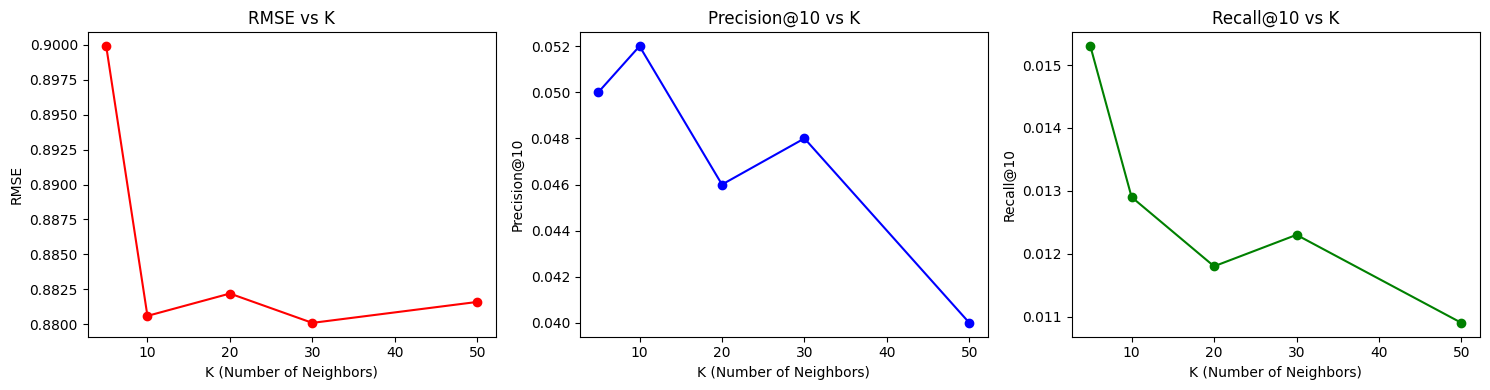

In [16]:
# Test with different values of K

print("Testing User-Based CF with different K values...")
k_values = [5, 10, 20, 30, 50]
results = []

for k in k_values:
    rmse, precision, recall = evaluate_user_cf(ratings, k_neighbors=k, sample_size=500)
    results.append({
        'K': k,
        'RMSE': round(rmse, 4),
        'Precision@10': round(precision, 4),
        'Recall@10': round(recall, 4)
    })
    print(f"K={k}: RMSE={rmse:.4f}, Precision@10={precision:.4f}, Recall@10={recall:.4f}")

results_df = pd.DataFrame(results)
display(results_df)

# Plot results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(k_values, [r['RMSE'] for r in results], 'o-', color='red')
axes[0].set_xlabel('K (Number of Neighbors)')
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE vs K')

axes[1].plot(k_values, [r['Precision@10'] for r in results], 'o-', color='blue')
axes[1].set_xlabel('K (Number of Neighbors)')
axes[1].set_ylabel('Precision@10')
axes[1].set_title('Precision@10 vs K')

axes[2].plot(k_values, [r['Recall@10'] for r in results], 'o-', color='green')
axes[2].set_xlabel('K (Number of Neighbors)')
axes[2].set_ylabel('Recall@10')
axes[2].set_title('Recall@10 vs K')

plt.tight_layout()
plt.show()

---
## Task 4: Item-Based Collaborative Filtering

Item-based CF recommends items based on their similarity to items a user has previously liked.


In [17]:
# Compute item-item similarity using cosine similarity
movie_user_matrix = user_movie_matrix.T
movie_user_filled = movie_user_matrix.fillna(0)
movie_ratings_array = movie_user_filled.values
movie_means = np.zeros(movie_ratings_array.shape[0])
for i in range(movie_ratings_array.shape[0]):
    rated = movie_ratings_array[i] > 0
    if rated.sum() > 0:
        movie_means[i] = movie_ratings_array[i][rated].mean()
movie_ratings_centered = movie_ratings_array.copy()
for i in range(movie_ratings_centered.shape[0]):
    mask = movie_ratings_centered[i] > 0
    movie_ratings_centered[i][mask] -= movie_means[i]
item_similarity = cosine_similarity(movie_ratings_centered)

print(f"Item similarity matrix shape: {item_similarity.shape}")
print("\nSample item similarities (first 5 movies):")
sample_movies = movie_user_matrix.index[:5]
item_sim_df = pd.DataFrame(item_similarity[:5, :5], 
                          index=sample_movies,
                          columns=sample_movies)
display(item_sim_df)

Item similarity matrix shape: (9724, 9724)

Sample item similarities (first 5 movies):


movieId,1,2,3,4,5
movieId,,,,,
1,1.000000,0.139649,0.113850,0.032658,0.076230
2,0.139649,1.000000,0.187303,-0.016897,0.154411
3,0.113850,0.187303,1.000000,0.071153,0.220868
4,0.032658,-0.016897,0.071153,1.000000,0.128339
5,0.076230,0.154411,0.220868,0.128339,1.000000


In [18]:
# Predict ratings for a given user based on similar items

def predict_rating_item_cf(user_id, movie_id, user_movie_matrix, item_similarity, 
                          movie_means, k=20):

    if user_id not in user_movie_matrix.index:
        return movie_means.mean()
    if movie_id not in user_movie_matrix.columns:
        return 3.0  
    
    movie_idx = user_movie_matrix.columns.get_loc(movie_id)
    user_ratings = user_movie_matrix.loc[user_id]
    rated_movies = user_ratings[~user_ratings.isna()].index.tolist()
    
    if len(rated_movies) == 0:
        return movie_means[movie_idx] if movie_idx < len(movie_means) else 3.0
    similarities = []
    ratings = []
    
    for rated_movie in rated_movies:
        if rated_movie in user_movie_matrix.columns:
            rated_idx = user_movie_matrix.columns.get_loc(rated_movie)
            sim = item_similarity[movie_idx, rated_idx]
            if sim > 0:  
                similarities.append(sim)
                ratings.append(user_ratings[rated_movie])
    
    if len(similarities) == 0:
        return movie_means[movie_idx] if movie_idx < len(movie_means) else 3.0
    
    sim_rating_pairs = list(zip(similarities, ratings))
    sim_rating_pairs = sorted(sim_rating_pairs, key=lambda x: x[0], reverse=True)[:k]
    
    weighted_sum = sum(sim * rating for sim, rating in sim_rating_pairs)
    sim_sum = sum(sim for sim, _ in sim_rating_pairs)
    
    if sim_sum == 0:
        return movie_means[movie_idx] if movie_idx < len(movie_means) else 3.0
    
    prediction = weighted_sum / sim_sum
    
    return np.clip(prediction, 0.5, 5.0)

print("Item-based CF prediction function created!")

test_user = 1
test_movie = ratings[ratings['userId'] == test_user].iloc[0]['movieId']
actual = ratings[(ratings['userId'] == test_user) & (ratings['movieId'] == test_movie)]['rating'].values[0]
predicted = predict_rating_item_cf(test_user, test_movie, user_movie_matrix, item_similarity, movie_means)
print(f"\nTest: User {test_user}, Movie {test_movie}")
print(f"Actual rating: {actual}, Predicted: {predicted:.2f}")

Item-based CF prediction function created!

Test: User 1, Movie 1.0
Actual rating: 4.0, Predicted: 4.27


In [19]:
#Generate top-N movie recommendations for a user

def get_item_cf_recommendations(user_id, user_movie_matrix, item_similarity, 
                               movie_means, movies_df, top_n=10, k=20):
    if user_id not in user_movie_matrix.index:
        return f"User {user_id} not found"
    user_ratings = user_movie_matrix.loc[user_id]
    unrated_movies = user_ratings[user_ratings.isna()].index.tolist()
    sample_movies = unrated_movies[:500] if len(unrated_movies) > 500 else unrated_movies
    predictions = []
    for movie_id in sample_movies:
        pred = predict_rating_item_cf(user_id, movie_id, user_movie_matrix, 
                                      item_similarity, movie_means, k)
        predictions.append((movie_id, pred))
    predictions = sorted(predictions, key=lambda x: x[1], reverse=True)[:top_n]
    
    results = []
    for movie_id, pred_rating in predictions:
        movie_info = movies_df[movies_df['movieId'] == movie_id]
        if len(movie_info) > 0:
            results.append({
                'movieId': movie_id,
                'title': movie_info['title'].values[0],
                'genres': movie_info['genres'].values[0],
                'predicted_rating': round(pred_rating, 2)
            })
    
    return pd.DataFrame(results)

print("Item-Based CF Recommendations for User 1:")
recommendations = get_item_cf_recommendations(1, user_movie_matrix, item_similarity, 
                                              movie_means, movies, top_n=10)
display(recommendations)

Item-Based CF Recommendations for User 1:


,movieId,title,genres,predicted_rating
0,53,Lamerica (1994),Adventure|Drama,5.00
1,99,Heidi Fleiss: Hollywood Madam (1995),Documentary,5.00
2,148,"Awfully Big Adventure, An (1995)",Drama,5.00
3,467,Live Nude Girls (1995),Comedy,5.00
4,495,In the Realm of the Senses (Ai no corrida) (1976),Drama,5.00
5,496,What Happened Was... (1994),Comedy|Drama|Romance|Thriller,5.00
6,626,"Thin Line Between Love and Hate, A (1996)",Comedy,5.00
7,633,Denise Calls Up (1995),Comedy,5.00
8,594,Snow White and the Seven Dwarfs (1937),Animation|Children|Drama|Fantasy|Musical,4.73
9,313,"Swan Princess, The (1994)",Animation|Children,4.72


In [20]:
# Evaluate item-based CF and compare with user-based CF

def evaluate_item_cf(ratings_df, k_neighbors=20, k_recommendations=10, threshold=4.0,
                    sample_size=1000):
    train_ratings, test_ratings = train_test_split(
        ratings_df, test_size=0.2, random_state=42
    )
    train_matrix = train_ratings.pivot(index='userId', columns='movieId', values='rating')
    train_item_matrix = train_matrix.T.fillna(0)
    train_item_array = train_item_matrix.values
    train_item_means = np.zeros(train_item_array.shape[0])
    for i in range(train_item_array.shape[0]):
        rated = train_item_array[i] > 0
        if rated.sum() > 0:
            train_item_means[i] = train_item_array[i][rated].mean()
    train_item_centered = train_item_array.copy()
    for i in range(train_item_centered.shape[0]):
        mask = train_item_centered[i] > 0
        train_item_centered[i][mask] -= train_item_means[i]
    
    train_item_sim = cosine_similarity(train_item_centered)
    test_sample = test_ratings.sample(n=min(sample_size, len(test_ratings)), random_state=42)
    
    predictions = []
    actuals = []
    
    for _, row in test_sample.iterrows():
        user_id = row['userId']
        movie_id = row['movieId']
        actual = row['rating']
        
        if user_id in train_matrix.index and movie_id in train_matrix.columns:
            pred = predict_rating_item_cf(user_id, movie_id, train_matrix, 
                                         train_item_sim, train_item_means, k_neighbors)
            predictions.append(pred)
            actuals.append(actual)
    
    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    precisions = []
    recalls = []
    
    test_users = test_ratings['userId'].unique()[:50]
    
    for user_id in test_users:
        if user_id not in train_matrix.index:
            continue
        
        user_test = test_ratings[test_ratings['userId'] == user_id]
        relevant = set(user_test[user_test['rating'] >= threshold]['movieId'])
        
        if len(relevant) == 0:
            continue
        
        user_ratings = train_matrix.loc[user_id]
        unrated = user_ratings[user_ratings.isna()].index.tolist()[:100]
        
        preds = []
        for movie_id in unrated:
            if movie_id in train_matrix.columns:
                pred = predict_rating_item_cf(user_id, movie_id, train_matrix,
                                             train_item_sim, train_item_means, k_neighbors)
                preds.append((movie_id, pred))
        
        preds = sorted(preds, key=lambda x: x[1], reverse=True)[:k_recommendations]
        recommended = set([m[0] for m in preds])
        
        hits = len(recommended & relevant)
        precisions.append(hits / k_recommendations)
        recalls.append(hits / len(relevant))
    
    return rmse, np.mean(precisions), np.mean(recalls)

print("Evaluating Item-Based Collaborative Filtering...")
item_cf_rmse, item_cf_precision, item_cf_recall = evaluate_item_cf(
    ratings, k_neighbors=20, sample_size=1000
)

print(f"\nComparison of User-Based vs Item-Based CF:")
print(f"{'='*50}")
print(f"{'Metric':<20}{'User-Based CF':<15}{'Item-Based CF':<15}")
print(f"{'='*50}")
print(f"{'RMSE':<20}{user_cf_rmse:<15.4f}{item_cf_rmse:<15.4f}")
print(f"{'Precision@10':<20}{user_cf_precision:<15.4f}{item_cf_precision:<15.4f}")
print(f"{'Recall@10':<20}{user_cf_recall:<15.4f}{item_cf_recall:<15.4f}")
print(f"{'='*50}")

Evaluating Item-Based Collaborative Filtering...

Comparison of User-Based vs Item-Based CF:
Metric              User-Based CF  Item-Based CF  
RMSE                0.8852         0.9165         
Precision@10        0.0460         0.0260         
Recall@10           0.0118         0.0101         


---
# Part 3: Matrix Factorization for Recommender Systems 

## Task 5: Implementing SVD for Recommendations


In [21]:
# Prepare the user-item matrix for factorization
user_item_df = ratings.pivot(index='userId', columns='movieId', values='rating')
user_means_svd = user_item_df.mean(axis=1)
user_item_normalized = user_item_df.sub(user_means_svd, axis=0)
user_item_normalized = user_item_normalized.fillna(0)

print(f"User-Item Matrix shape: {user_item_normalized.shape}")
print(f"Global mean rating: {ratings['rating'].mean():.2f}")
print("\nSample of normalized matrix:")
display(user_item_normalized.iloc[:5, :5])

User-Item Matrix shape: (610, 9724)
Global mean rating: 3.50

Sample of normalized matrix:


movieId,1,2,3,4,5
userId,,,,,
1,-0.366379,0.0,-0.366379,0.0,0.0
2,0.000000,0.0,0.000000,0.0,0.0
3,0.000000,0.0,0.000000,0.0,0.0
4,0.000000,0.0,0.000000,0.0,0.0
5,0.363636,0.0,0.000000,0.0,0.0


SVD Results:
U shape (User latent factors): (610, 50)
Sigma shape (Singular values): (50,)
Vt shape (Item latent factors): (50, 9724)

Top 10 singular values: [76.20046537 43.6224036  41.77917206 39.37050585 37.95619249 36.54895519
 35.33542922 34.22406866 33.7660431  33.15013963]


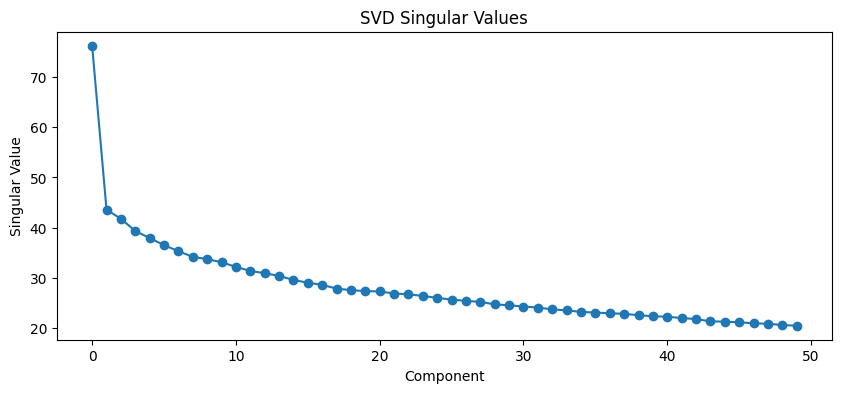

In [22]:
# Apply Singular Value Decomposition (SVD)
k = 50  # Number of latent factors

U, sigma, Vt = svds(user_item_normalized.values, k=k)

print(f"SVD Results:")
print(f"U shape (User latent factors): {U.shape}")
print(f"Sigma shape (Singular values): {sigma.shape}")
print(f"Vt shape (Item latent factors): {Vt.shape}")
sigma_diag = np.diag(sigma)

print(f"\nTop 10 singular values: {sigma[::-1][:10]}")

# Plot singular values
plt.figure(figsize=(10, 4))
plt.plot(sigma[::-1], 'o-')
plt.xlabel('Component')
plt.ylabel('Singular Value')
plt.title('SVD Singular Values')
plt.show()

In [23]:
# Predict missing ratings using reconstructed matrix
R_reconstructed = np.dot(np.dot(U, sigma_diag), Vt)
R_predicted = R_reconstructed + user_means_svd.values.reshape(-1, 1)
R_predicted = np.clip(R_predicted, 0.5, 5.0)
predictions_df = pd.DataFrame(R_predicted, 
                             index=user_item_df.index, 
                             columns=user_item_df.columns)

print("Predicted ratings matrix created!")
print(f"Shape: {predictions_df.shape}")
print("\nSample predictions:")
display(predictions_df.iloc[:5, :5])
test_user = 1
test_movie = 1
actual = user_item_df.loc[test_user, test_movie] if not pd.isna(user_item_df.loc[test_user, test_movie]) else "Not rated"
predicted = predictions_df.loc[test_user, test_movie]
print(f"\nUser {test_user}, Movie {test_movie}: Actual={actual}, Predicted={predicted:.2f}")

Predicted ratings matrix created!
Shape: (610, 9724)

Sample predictions:


movieId,1,2,3,4,5
userId,,,,,
1,4.306161,4.296397,4.405951,4.370563,4.342908
2,3.945985,3.932260,3.936752,3.953256,3.956456
3,2.425206,2.473104,2.404444,2.442252,2.462691
4,3.591391,3.542791,3.567743,3.501296,3.618028
5,3.826923,3.623178,3.619512,3.618412,3.607475



User 1, Movie 1: Actual=4.0, Predicted=4.31


In [24]:
# SVD-based recommendation function

def get_svd_recommendations(user_id, predictions_df, user_item_df, movies_df, top_n=10):
    if user_id not in predictions_df.index:
        return f"User {user_id} not found"
    user_predictions = predictions_df.loc[user_id]
    actual_ratings = user_item_df.loc[user_id]
    unrated_mask = actual_ratings.isna()
    unrated_predictions = user_predictions[unrated_mask]
    top_movies = unrated_predictions.nlargest(top_n)
    results = []
    for movie_id, pred_rating in top_movies.items():
        movie_info = movies_df[movies_df['movieId'] == movie_id]
        if len(movie_info) > 0:
            results.append({
                'movieId': movie_id,
                'title': movie_info['title'].values[0],
                'genres': movie_info['genres'].values[0],
                'predicted_rating': round(pred_rating, 2)
            })
    
    return pd.DataFrame(results)

print("SVD Recommendations for User 1:")
svd_recs = get_svd_recommendations(1, predictions_df, user_item_df, movies)
display(svd_recs)

SVD Recommendations for User 1:


,movieId,title,genres,predicted_rating
0,541,Blade Runner (1982),Action|Sci-Fi|Thriller,4.71
1,344,Ace Ventura: Pet Detective (1994),Comedy,4.68
2,5952,"Lord of the Rings: The Two Towers, The (2002)",Adventure|Fantasy,4.66
3,2804,"Christmas Story, A (1983)",Children|Comedy,4.66
4,4993,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy,4.62
5,7153,"Lord of the Rings: The Return of the King, The...",Action|Adventure|Drama|Fantasy,4.62
6,1246,Dead Poets Society (1989),Drama,4.59
7,4011,Snatch (2000),Comedy|Crime|Thriller,4.59
8,858,"Godfather, The (1972)",Crime|Drama,4.59
9,2300,"Producers, The (1968)",Comedy,4.58


In [25]:
# Evaluate SVD-based recommendations

def evaluate_svd(ratings_df, k_factors=50, k_recommendations=10, threshold=4.0):
    train_ratings, test_ratings = train_test_split(
        ratings_df, test_size=0.2, random_state=42
    )
    train_matrix = train_ratings.pivot(index='userId', columns='movieId', values='rating')
    train_means = train_matrix.mean(axis=1)
    train_normalized = train_matrix.sub(train_means, axis=0).fillna(0)
    U, sigma, Vt = svds(train_normalized.values, k=k_factors)
    sigma_diag = np.diag(sigma)
    R_pred = np.dot(np.dot(U, sigma_diag), Vt) + train_means.values.reshape(-1, 1)
    R_pred = np.clip(R_pred, 0.5, 5.0)
    
    pred_df = pd.DataFrame(R_pred, index=train_matrix.index, columns=train_matrix.columns)
    predictions = []
    actuals = []
    
    for _, row in test_ratings.iterrows():
        user_id = row['userId']
        movie_id = row['movieId']
        actual = row['rating']
        
        if user_id in pred_df.index and movie_id in pred_df.columns:
            pred = pred_df.loc[user_id, movie_id]
            predictions.append(pred)
            actuals.append(actual)
    
    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    precisions = []
    recalls = []
    
    test_users = test_ratings['userId'].unique()[:100]
    
    for user_id in test_users:
        if user_id not in pred_df.index:
            continue
        
        user_test = test_ratings[test_ratings['userId'] == user_id]
        relevant = set(user_test[user_test['rating'] >= threshold]['movieId'])
        
        if len(relevant) == 0:
            continue
        actual_ratings = train_matrix.loc[user_id]
        unrated_mask = actual_ratings.isna()
        user_preds = pred_df.loc[user_id][unrated_mask]
        top_k = user_preds.nlargest(k_recommendations).index.tolist()
        
        recommended = set(top_k)
        hits = len(recommended & relevant)
        
        precisions.append(hits / k_recommendations)
        recalls.append(hits / len(relevant))
    
    return rmse, np.mean(precisions), np.mean(recalls)

print("Evaluating SVD-based Recommendations...")
svd_rmse, svd_precision, svd_recall = evaluate_svd(ratings, k_factors=50)

print(f"\nComparison of All Methods:")
print(f"{'='*60}")
print(f"{'Metric':<15}{'User-Based CF':<15}{'Item-Based CF':<15}{'SVD':<15}")
print(f"{'='*60}")
print(f"{'RMSE':<15}{user_cf_rmse:<15.4f}{item_cf_rmse:<15.4f}{svd_rmse:<15.4f}")
print(f"{'Precision@10':<15}{user_cf_precision:<15.4f}{item_cf_precision:<15.4f}{svd_precision:<15.4f}")
print(f"{'Recall@10':<15}{user_cf_recall:<15.4f}{item_cf_recall:<15.4f}{svd_recall:<15.4f}")
print(f"{'='*60}")

Evaluating SVD-based Recommendations...

Comparison of All Methods:
Metric         User-Based CF  Item-Based CF  SVD            
RMSE           0.8852         0.9165         0.9304         
Precision@10   0.0460         0.0260         0.1910         
Recall@10      0.0118         0.0101         0.0966         


---
## Task 6: Implementing Matrix Factorization with the Surprise Library


In [26]:
# Load dataset into Surprise framework

from surprise import Dataset, Reader, SVD, accuracy
from surprise.model_selection import train_test_split as surprise_split
from surprise.model_selection import cross_validate, GridSearchCV
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)
trainset, testset = surprise_split(data, test_size=0.2, random_state=42)

print(f"Training set size: {trainset.n_ratings}")
print(f"Test set size: {len(testset)}")
print(f"Number of users: {trainset.n_users}")
print(f"Number of items: {trainset.n_items}")

Training set size: 80668
Test set size: 20168
Number of users: 610
Number of items: 8928


In [27]:
#Train SVD model and tune hyperparameters
param_grid = {
    'n_factors': [20, 50, 100],
    'n_epochs': [20, 30],
    'lr_all': [0.005, 0.01],
    'reg_all': [0.02, 0.1]
}

print("Performing grid search (this may take a few minutes)...")
gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=3, n_jobs=-1)
gs.fit(data)

print(f"Best RMSE score: {gs.best_score['rmse']:.4f}")
print(f"Best parameters: {gs.best_params['rmse']}")

best_params = gs.best_params['rmse']
svd_surprise = SVD(**best_params, random_state=42)
svd_surprise.fit(trainset)

print("\nModel trained with best parameters!")

Performing grid search (this may take a few minutes)...
Best RMSE score: 0.8632
Best parameters: {'n_factors': 100, 'n_epochs': 30, 'lr_all': 0.01, 'reg_all': 0.1}

Model trained with best parameters!


In [28]:
# Evaluate model performance
predictions_surprise = svd_surprise.test(testset)
rmse_surprise = accuracy.rmse(predictions_surprise)
mae_surprise = accuracy.mae(predictions_surprise)

print(f"\nSurprise SVD Performance:")
print(f"RMSE: {rmse_surprise:.4f}")
print(f"MAE: {mae_surprise:.4f}")
from collections import defaultdict

def precision_recall_at_k(predictions, k=10, threshold=4.0):
    user_est_true = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))
    
    precisions = []
    recalls = []
    
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        top_k = user_ratings[:k]
        n_relevant = sum(1 for (_, true_r) in user_ratings if true_r >= threshold)
        n_rec_relevant = sum(1 for (est, true_r) in top_k if true_r >= threshold)
        
        if n_relevant > 0:
            precisions.append(n_rec_relevant / k)
            recalls.append(n_rec_relevant / n_relevant)
    
    return np.mean(precisions), np.mean(recalls)

precision_surprise, recall_surprise = precision_recall_at_k(predictions_surprise, k=10, threshold=4.0)
print(f"Precision@10: {precision_surprise:.4f}")
print(f"Recall@10: {recall_surprise:.4f}")

RMSE: 0.8613
MAE:  0.6604

Surprise SVD Performance:
RMSE: 0.8613
MAE: 0.6604
Precision@10: 0.5827
Recall@10: 0.6851


In [29]:
# Compare Surprise SVD with custom SVD implementation

print("Comparison: Custom SVD vs Surprise SVD")
print(f"{'='*50}")
print(f"{'Metric':<20}{'Custom SVD':<15}{'Surprise SVD':<15}")
print(f"{'='*50}")
print(f"{'RMSE':<20}{svd_rmse:<15.4f}{rmse_surprise:<15.4f}")
print(f"{'Precision@10':<20}{svd_precision:<15.4f}{precision_surprise:<15.4f}")
print(f"{'Recall@10':<20}{svd_recall:<15.4f}{recall_surprise:<15.4f}")
print(f"{'='*50}")



Comparison: Custom SVD vs Surprise SVD
Metric              Custom SVD     Surprise SVD   
RMSE                0.9304         0.8613         
Precision@10        0.1910         0.5827         
Recall@10           0.0966         0.6851         


---
# Part 4: Hybrid Recommendation Model

## Task 7: Implementing a Meta-Learning Hybrid Model

Combining Content-Based Filtering and Collaborative Filtering using a meta-learning approach.


In [30]:
#  Prepare features for meta-learning model

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge

movie_popularity = ratings.groupby('movieId')['rating'].agg(['mean', 'count'])
movie_popularity.columns = ['avg_rating', 'rating_count']

user_avg_rating = ratings.groupby('userId')['rating'].mean()

def get_cbf_score(user_id, movie_id):
    if user_id not in user_profiles:
        return 0.0
    
    if movie_id not in movie_id_to_idx.index:
        return 0.0
    
    movie_idx = movie_id_to_idx[movie_id]
    user_profile = user_profiles[user_id].reshape(1, -1)
    movie_vector = tfidf_matrix[movie_idx].toarray()
    
    similarity = cosine_similarity(user_profile, movie_vector)[0][0]
    return similarity

def get_cf_score(user_id, movie_id):

    if user_id in predictions_df.index and movie_id in predictions_df.columns:
        return predictions_df.loc[user_id, movie_id]
    return 3.0  

print("Preparing training data for meta-learning model...")


meta_features = []
meta_targets = []

sample_ratings = ratings.sample(n=min(10000, len(ratings)), random_state=42)

for _, row in sample_ratings.iterrows():
    user_id = row['userId']
    movie_id = row['movieId']
    actual_rating = row['rating']
    cbf_score = get_cbf_score(user_id, movie_id)

    cf_score = get_cf_score(user_id, movie_id)
    if movie_id in movie_popularity.index:
        pop_score = movie_popularity.loc[movie_id, 'avg_rating']
        rating_count = movie_popularity.loc[movie_id, 'rating_count']
    else:
        pop_score = 3.0
        rating_count = 0
    user_avg = user_avg_rating[user_id] if user_id in user_avg_rating.index else 3.0
    
    meta_features.append([cbf_score, cf_score, pop_score, user_avg, rating_count])
    meta_targets.append(actual_rating)

X_meta = np.array(meta_features)
y_meta = np.array(meta_targets)

print(f"Meta-learning training data shape: {X_meta.shape}")
print(f"Feature names: ['CBF Score', 'CF Score', 'Movie Popularity', 'User Avg Rating', 'Rating Count']")

Preparing training data for meta-learning model...
Meta-learning training data shape: (10000, 5)
Feature names: ['CBF Score', 'CF Score', 'Movie Popularity', 'User Avg Rating', 'Rating Count']


In [31]:
#  Train meta-learning model


X_train_meta, X_test_meta, y_train_meta, y_test_meta = train_test_split(
    X_meta, y_meta, test_size=0.2, random_state=42
)

models = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)
}

best_model = None
best_rmse = float('inf')
best_model_name = ""

print("Training Meta-Learning Models...")
print(f"{'='*50}")

for name, model in models.items():
    model.fit(X_train_meta, y_train_meta)
    y_pred = model.predict(X_test_meta)
    rmse = np.sqrt(mean_squared_error(y_test_meta, y_pred))
    
    print(f"{name}: RMSE = {rmse:.4f}")
    
    if rmse < best_rmse:
        best_rmse = rmse
        best_model = model
        best_model_name = name

print(f"\nBest model: {best_model_name} with RMSE = {best_rmse:.4f}")

Training Meta-Learning Models...
Ridge Regression: RMSE = 0.6002
Random Forest: RMSE = 0.5433
Gradient Boosting: RMSE = 0.5534

Best model: Random Forest with RMSE = 0.5433


In [32]:
# Evaluate hybrid model

def evaluate_hybrid_model(model, ratings_df, k_recommendations=10, threshold=4.0):
    train_ratings, test_ratings = train_test_split(
        ratings_df, test_size=0.2, random_state=42
    )
    
    precisions = []
    recalls = []
    
    test_users = test_ratings['userId'].unique()[:50]  
    
    for user_id in test_users:
        
        user_test = test_ratings[test_ratings['userId'] == user_id]
        relevant = set(user_test[user_test['rating'] >= threshold]['movieId'])
        
        if len(relevant) == 0:
            continue
        train_movies = set(train_ratings[train_ratings['userId'] == user_id]['movieId'])
        all_movies = movies['movieId'].unique()
        candidates = [m for m in all_movies if m not in train_movies][:200]
        
        preds = []
        for movie_id in candidates:
            cbf_score = get_cbf_score(user_id, movie_id)
            cf_score = get_cf_score(user_id, movie_id)
            
            if movie_id in movie_popularity.index:
                pop_score = movie_popularity.loc[movie_id, 'avg_rating']
                rating_count = movie_popularity.loc[movie_id, 'rating_count']
            else:
                pop_score = 3.0
                rating_count = 0
            
            user_avg = user_avg_rating[user_id] if user_id in user_avg_rating.index else 3.0
            
            features = np.array([[cbf_score, cf_score, pop_score, user_avg, rating_count]])
            pred = model.predict(features)[0]
            preds.append((movie_id, pred))
        preds = sorted(preds, key=lambda x: x[1], reverse=True)[:k_recommendations]
        recommended = set([m[0] for m in preds])
        
        hits = len(recommended & relevant)
        precisions.append(hits / k_recommendations)
        recalls.append(hits / len(relevant))
    
    return np.mean(precisions), np.mean(recalls)

print("Evaluating Hybrid Model...")
hybrid_precision, hybrid_recall = evaluate_hybrid_model(best_model, ratings)

print(f"\nHybrid Model Performance:")
print(f"Precision@10: {hybrid_precision:.4f}")
print(f"Recall@10: {hybrid_recall:.4f}")


print(f"\n{'='*70}")
print(f"{'Method':<25}{'RMSE':<15}{'Precision@10':<15}{'Recall@10':<15}")
print(f"{'='*70}")
print(f"{'User-Based CF':<25}{user_cf_rmse:<15.4f}{user_cf_precision:<15.4f}{user_cf_recall:<15.4f}")
print(f"{'Item-Based CF':<25}{item_cf_rmse:<15.4f}{item_cf_precision:<15.4f}{item_cf_recall:<15.4f}")
print(f"{'SVD':<25}{svd_rmse:<15.4f}{svd_precision:<15.4f}{svd_recall:<15.4f}")
print(f"{'Surprise SVD':<25}{rmse_surprise:<15.4f}{precision_surprise:<15.4f}{recall_surprise:<15.4f}")
print(f"{'Hybrid (Meta-Learning)':<25}{best_rmse:<15.4f}{hybrid_precision:<15.4f}{hybrid_recall:<15.4f}")
print(f"{'='*70}")

Evaluating Hybrid Model...

Hybrid Model Performance:
Precision@10: 0.1600
Recall@10: 0.0339

Method                   RMSE           Precision@10   Recall@10      
User-Based CF            0.8852         0.0460         0.0118         
Item-Based CF            0.9165         0.0260         0.0101         
SVD                      0.9304         0.1910         0.0966         
Surprise SVD             0.8613         0.5827         0.6851         
Hybrid (Meta-Learning)   0.5433         0.1600         0.0339         


In [33]:
# Analyze performance on cold-start users

def analyze_cold_start(model, ratings_df, cold_threshold=5):

    user_rating_counts = ratings_df.groupby('userId').size()
    cold_users = user_rating_counts[user_rating_counts <= cold_threshold].index.tolist()
    warm_users = user_rating_counts[user_rating_counts > cold_threshold].index.tolist()
    
    print(f"Cold-start users (≤{cold_threshold} ratings): {len(cold_users)}")
    print(f"Warm users (>{cold_threshold} ratings): {len(warm_users)}")
    cold_ratings = ratings_df[ratings_df['userId'].isin(cold_users)]
    warm_ratings = ratings_df[ratings_df['userId'].isin(warm_users)]
    
    def evaluate_subset(subset_ratings):
        if len(subset_ratings) == 0:
            return 0
        
        errors = []
        sample = subset_ratings.sample(min(500, len(subset_ratings)), random_state=42)
        
        for _, row in sample.iterrows():
            user_id = row['userId']
            movie_id = row['movieId']
            actual = row['rating']
            
            cbf_score = get_cbf_score(user_id, movie_id)
            cf_score = get_cf_score(user_id, movie_id)
            
            if movie_id in movie_popularity.index:
                pop_score = movie_popularity.loc[movie_id, 'avg_rating']
                rating_count = movie_popularity.loc[movie_id, 'rating_count']
            else:
                pop_score = 3.0
                rating_count = 0
            
            user_avg = user_avg_rating[user_id] if user_id in user_avg_rating.index else 3.0
            
            features = np.array([[cbf_score, cf_score, pop_score, user_avg, rating_count]])
            pred = model.predict(features)[0]
            errors.append((pred - actual) ** 2)
        
        return np.sqrt(np.mean(errors))
    
    cold_rmse = evaluate_subset(cold_ratings) if len(cold_ratings) > 0 else float('nan')
    warm_rmse = evaluate_subset(warm_ratings)
    
    return cold_rmse, warm_rmse

cold_rmse, warm_rmse = analyze_cold_start(best_model, ratings, cold_threshold=10)

print(f"\nCold-Start Analysis:")
print(f"{'='*40}")
print(f"Cold-start users RMSE: {cold_rmse:.4f}")
print(f"Warm users RMSE: {warm_rmse:.4f}")
print(f"{'='*40}")



Cold-start users (≤10 ratings): 0
Warm users (>10 ratings): 610

Cold-Start Analysis:
Cold-start users RMSE: nan
Warm users RMSE: 0.4572


---
# Part 5: Learning-Based Recommender Systems 

## Task 8: Content-Based Filtering with a Neural Network


In [34]:
# Load and process data for neural network

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, Dense, Concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


all_genres = set()
for genres in movies['genres']:
    if genres != '(no genres listed)':
        all_genres.update(genres.split('|'))

all_genres = sorted(list(all_genres))
genre_to_idx = {g: i for i, g in enumerate(all_genres)}

print(f"Number of unique genres: {len(all_genres)}")
print(f"Genres: {all_genres}")


def encode_genres(genres_str):
    encoding = np.zeros(len(all_genres))
    if genres_str != '(no genres listed)':
        for g in genres_str.split('|'):
            if g in genre_to_idx:
                encoding[genre_to_idx[g]] = 1
    return encoding

movies['genre_encoding'] = movies['genres'].apply(encode_genres)


def extract_year(title):
    try:
        year = int(title.strip()[-5:-1])
        if 1900 <= year <= 2030:
            return year
    except:
        pass
    return 2000  

movies['year'] = movies['title'].apply(extract_year)

movie_avg_ratings = ratings.groupby('movieId')['rating'].mean()
movies['avg_rating'] = movies['movieId'].map(movie_avg_ratings).fillna(3.0)

print("\nMovie features sample:")
display(movies[['movieId', 'title', 'genres', 'year', 'avg_rating']].head())

I0000 00:00:1773850999.405619  484476 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773850999.406890  484476 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773851000.954647  484476 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773851000.955199  484476 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Number of unique genres: 19
Genres: ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

Movie features sample:


,movieId,title,genres,year,avg_rating
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995,3.920930
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995,3.431818
2,3,Grumpier Old Men (1995),Comedy|Romance,1995,3.259615
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995,2.357143
4,5,Father of the Bride Part II (1995),Comedy,1995,3.071429


In [35]:
# Create user features (average rating per genre)

def calculate_user_genre_preferences(ratings_df, movies_df, all_genres):
    user_genre_prefs = {}
    
    ratings_with_genres = ratings_df.merge(movies_df[['movieId', 'genres']], on='movieId')
    
    for user_id in ratings_df['userId'].unique():
        user_ratings = ratings_with_genres[ratings_with_genres['userId'] == user_id]
        
        genre_ratings = {g: [] for g in all_genres}
        
        for _, row in user_ratings.iterrows():
            if row['genres'] != '(no genres listed)':
                for g in row['genres'].split('|'):
                    if g in genre_ratings:
                        genre_ratings[g].append(row['rating'])
        
        user_prefs = []
        for g in all_genres:
            if len(genre_ratings[g]) > 0:
                user_prefs.append(np.mean(genre_ratings[g]))
            else:
                user_prefs.append(3.0)  
        
        user_genre_prefs[user_id] = np.array(user_prefs)
    
    return user_genre_prefs

print("Calculating user genre preferences...")
user_genre_prefs_nn = calculate_user_genre_preferences(ratings, movies, all_genres)
print(f"Calculated preferences for {len(user_genre_prefs_nn)} users")

Calculating user genre preferences...
Calculated preferences for 610 users


In [36]:
# Create neural network for user and item embeddings

def create_content_based_nn(n_genres, embedding_dim=32):

    user_input = Input(shape=(n_genres,), name='user_input')
    user_dense = Dense(64, activation='relu')(user_input)
    user_dense = Dropout(0.3)(user_dense)
    user_embedding = Dense(embedding_dim, activation='relu', name='user_embedding')(user_dense)
    movie_input = Input(shape=(n_genres + 2,), name='movie_input')  
    movie_dense = Dense(64, activation='relu')(movie_input)
    movie_dense = Dropout(0.3)(movie_dense)
    movie_embedding = Dense(embedding_dim, activation='relu', name='movie_embedding')(movie_dense)
    
    
    merged = Concatenate()([user_embedding, movie_embedding])
    
    dense1 = Dense(64, activation='relu')(merged)
    dense1 = Dropout(0.3)(dense1)
    dense2 = Dense(32, activation='relu')(dense1)
    output = Dense(1, activation='linear', name='rating_output')(dense2)
    

    model = Model(inputs=[user_input, movie_input], outputs=output)
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    return model

n_genres = len(all_genres)
model_nn = create_content_based_nn(n_genres)
model_nn.summary()

E0000 00:00:1773851004.401215  484476 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_input         │ (None, 21)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      1,280 │ user_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      1,408 │ movie_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 32)        │      2,080 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_embedding     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ user_embedding[0… │
│ (Concatenate)       │                   │            │ movie_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      4,160 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rating_output       │ (None, 1)         │         33 │ dense_3[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,121 (51.25 KB)

 Trainable params: 13,121 (51.25 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
#  Prepare training data and train the model

def prepare_nn_training_data(ratings_df, movies_df, user_genre_prefs, all_genres):
    X_user = []
    X_movie = []
    y = []
    
    movie_features = {}
    for _, row in movies_df.iterrows():
        movie_id = row['movieId']
        genre_enc = row['genre_encoding']
        year_normalized = (row['year'] - 1900) / 120  
        avg_rating_normalized = row['avg_rating'] / 5.0
        movie_features[movie_id] = np.concatenate([genre_enc, [year_normalized, avg_rating_normalized]])
    
    for _, row in ratings_df.iterrows():
        user_id = row['userId']
        movie_id = row['movieId']
        rating = row['rating']
        
        if user_id in user_genre_prefs and movie_id in movie_features:
            X_user.append(user_genre_prefs[user_id])
            X_movie.append(movie_features[movie_id])
            y.append(rating)
    
    return np.array(X_user), np.array(X_movie), np.array(y)

print("Preparing training data...")
X_user_nn, X_movie_nn, y_nn = prepare_nn_training_data(ratings, movies, user_genre_prefs_nn, all_genres)

print(f"User features shape: {X_user_nn.shape}")
print(f"Movie features shape: {X_movie_nn.shape}")
print(f"Labels shape: {y_nn.shape}")


X_user_train, X_user_test, X_movie_train, X_movie_test, y_train_nn, y_test_nn = train_test_split(
    X_user_nn, X_movie_nn, y_nn, test_size=0.2, random_state=42
)

print(f"\nTraining samples: {len(y_train_nn)}")
print(f"Test samples: {len(y_test_nn)}")

Preparing training data...
User features shape: (100836, 19)
Movie features shape: (100836, 21)
Labels shape: (100836,)

Training samples: 80668
Test samples: 20168


Training neural network model...
Epoch 1/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.8179 - mae: 1.0006 - val_loss: 1.8679 - val_mae: 1.1853
Epoch 2/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9463 - mae: 0.7644 - val_loss: 2.2123 - val_mae: 1.3116
Epoch 3/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8327 - mae: 0.7131 - val_loss: 2.4270 - val_mae: 1.3856
Epoch 4/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7801 - mae: 0.6862 - val_loss: 2.2119 - val_mae: 1.3172
Epoch 5/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7540 - mae: 0.6721 - val_loss: 2.0558 - val_mae: 1.2634
Epoch 6/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7357 - mae: 0.6628 - val_loss: 2.4914 - val_mae: 1.4092


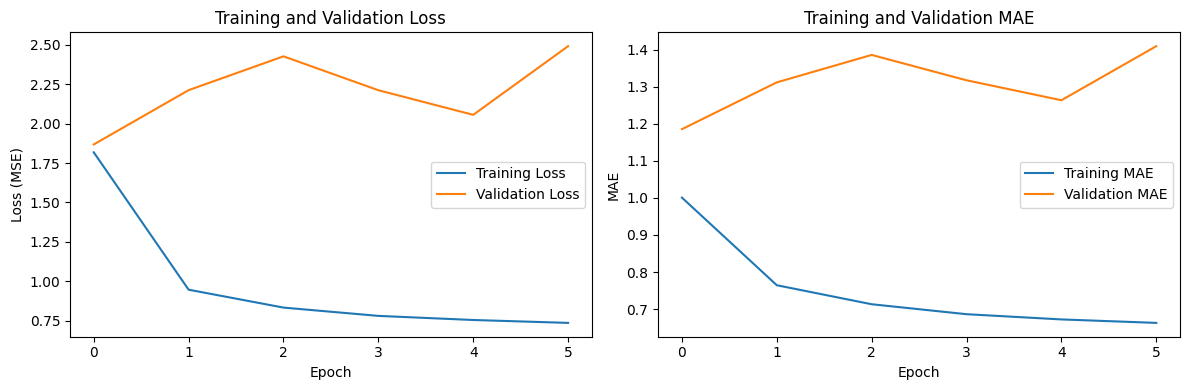

In [38]:
# Train the neural network model

print("Training neural network model...")

# Early stopping callback
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train model
history = model_nn.fit(
    [X_user_train, X_movie_train],
    y_train_nn,
    epochs=30,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Training MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('Training and Validation MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

In [39]:
# Evaluate neural network performance

y_pred_nn = model_nn.predict([X_user_test, X_movie_test], verbose=0).flatten()

y_pred_nn = np.clip(y_pred_nn, 0.5, 5.0)

nn_rmse = np.sqrt(mean_squared_error(y_test_nn, y_pred_nn))
nn_mae = np.mean(np.abs(y_test_nn - y_pred_nn))

print(f"Neural Network Content-Based Filtering Results:")
print(f"RMSE: {nn_rmse:.4f}")
print(f"MAE: {nn_mae:.4f}")



Neural Network Content-Based Filtering Results:
RMSE: 1.3668
MAE: 1.1895


---
## Task 9: Reinforcement Learning in Recommender Systems


In [40]:
# Define the environment (user-item interaction space)

class RecommenderEnvironment:
    
    def __init__(self, ratings_df, movies_df, all_genres):
        self.ratings = ratings_df
        self.movies = movies_df
        self.all_genres = all_genres
        
        self.movie_ids = movies_df['movieId'].unique()
        self.movie_to_idx = {m: i for i, m in enumerate(self.movie_ids)}
        self.idx_to_movie = {i: m for m, i in self.movie_to_idx.items()}
        
        self.user_ids = ratings_df['userId'].unique()
        self.user_movie_ratings = {}
        for _, row in ratings_df.iterrows():
            key = (row['userId'], row['movieId'])
            self.user_movie_ratings[key] = row['rating']
        
        self.n_arms = len(self.movie_ids)
    
    def get_reward(self, user_id, movie_id):

        key = (user_id, movie_id)
        if key in self.user_movie_ratings:
            rating = self.user_movie_ratings[key]
            if rating >= 4:
                return 1  
            else:
                return -1  
        return 0  
    
    def get_state(self, user_id):
        if user_id in user_genre_prefs_nn:
            return user_genre_prefs_nn[user_id]
        return np.zeros(len(self.all_genres))

env = RecommenderEnvironment(ratings, movies, all_genres)
print(f"Environment created with {env.n_arms} arms (movies)")
print(f"Number of users: {len(env.user_ids)}")

Environment created with 9742 arms (movies)
Number of users: 610


Training ε-Greedy Multi-Armed Bandit...
Total rewards: 1164
Average reward: 0.1164


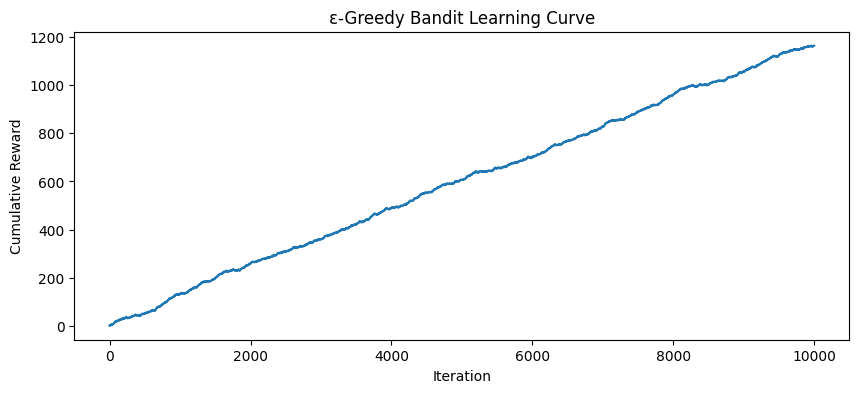

In [41]:
#  Implement Multi-Armed Bandit (ε-Greedy)

class EpsilonGreedyBandit:
    
    def __init__(self, n_arms, epsilon=0.1):
        self.n_arms = n_arms
        self.epsilon = epsilon
        
        self.Q = np.zeros(n_arms)
        
        self.N = np.zeros(n_arms)
    
    def select_action(self):
        
        if np.random.random() < self.epsilon:
            
            return np.random.randint(self.n_arms)
        else:

            return np.argmax(self.Q)
    
    def update(self, action, reward):
        
        self.N[action] += 1

        self.Q[action] += (reward - self.Q[action]) / self.N[action]
    
    def get_top_k_recommendations(self, k=10):
        
        return np.argsort(self.Q)[-k:][::-1]


print("Training ε-Greedy Multi-Armed Bandit...")

bandit_greedy = EpsilonGreedyBandit(env.n_arms, epsilon=0.1)

n_iterations = 10000
rewards_history = []

for i in range(n_iterations):

    user_id = np.random.choice(env.user_ids)
    
    action = bandit_greedy.select_action()
    movie_id = env.idx_to_movie[action]
    
    reward = env.get_reward(user_id, movie_id)
    
    bandit_greedy.update(action, reward)
    
    rewards_history.append(reward)

cumulative_rewards = np.cumsum(rewards_history)

print(f"Total rewards: {sum(rewards_history)}")
print(f"Average reward: {np.mean(rewards_history):.4f}")

# Plot learning curve
plt.figure(figsize=(10, 4))
plt.plot(cumulative_rewards)
plt.xlabel('Iteration')
plt.ylabel('Cumulative Reward')
plt.title('ε-Greedy Bandit Learning Curve')
plt.show()

Training UCB Multi-Armed Bandit...
UCB Total rewards: -19
UCB Average reward: -0.0019


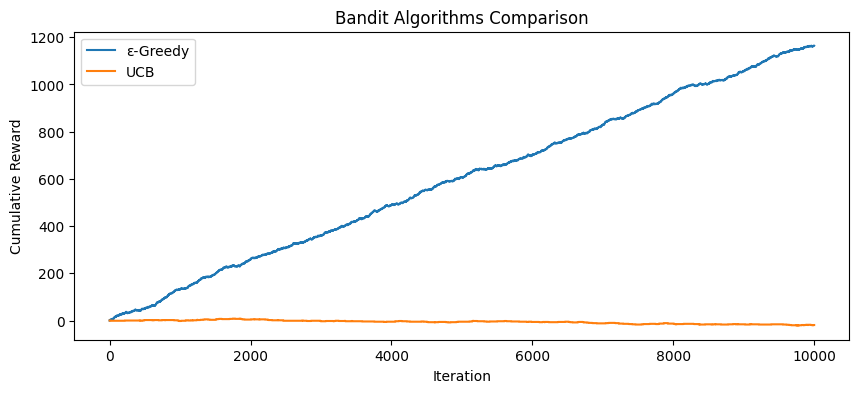

In [42]:
# Implement UCB (Upper Confidence Bound) Bandit

class UCBBandit:
    
    def __init__(self, n_arms, c=2):
        self.n_arms = n_arms
        self.c = c  
        
        self.Q = np.zeros(n_arms)
        self.N = np.zeros(n_arms)
        self.t = 0
    
    def select_action(self):

        self.t += 1
        
        unvisited = np.where(self.N == 0)[0]
        if len(unvisited) > 0:
            return np.random.choice(unvisited)
        

        ucb_values = self.Q + self.c * np.sqrt(np.log(self.t) / self.N)
        return np.argmax(ucb_values)
    
    def update(self, action, reward):
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]


print("Training UCB Multi-Armed Bandit...")

bandit_ucb = UCBBandit(env.n_arms, c=2)
rewards_ucb = []

for i in range(n_iterations):
    user_id = np.random.choice(env.user_ids)
    action = bandit_ucb.select_action()
    movie_id = env.idx_to_movie[action]
    reward = env.get_reward(user_id, movie_id)
    bandit_ucb.update(action, reward)
    rewards_ucb.append(reward)

print(f"UCB Total rewards: {sum(rewards_ucb)}")
print(f"UCB Average reward: {np.mean(rewards_ucb):.4f}")

# Compare
plt.figure(figsize=(10, 4))
plt.plot(np.cumsum(rewards_history), label='ε-Greedy')
plt.plot(np.cumsum(rewards_ucb), label='UCB')
plt.xlabel('Iteration')
plt.ylabel('Cumulative Reward')
plt.title('Bandit Algorithms Comparison')
plt.legend()
plt.show()

Training Q-Learning Recommender...
Q-Learning Total rewards: -27
Q-Learning Average reward: -0.0054


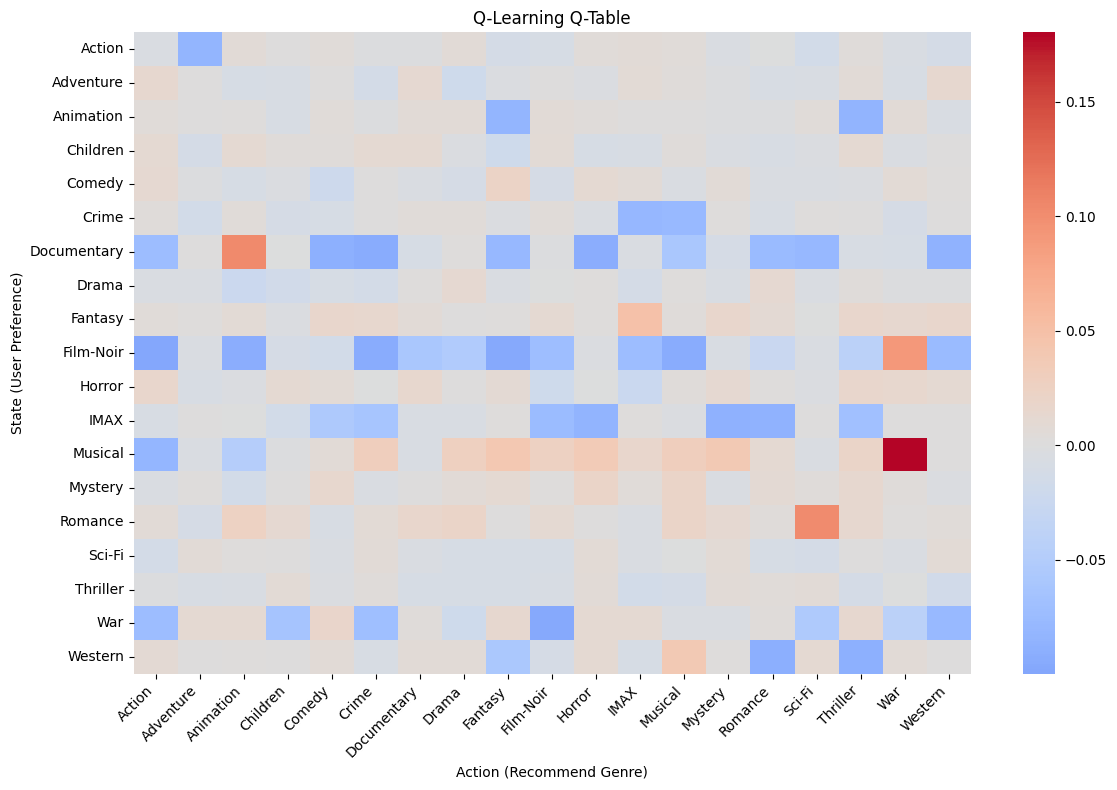

In [43]:
#  Implement Q-Learning agent

class QLearningRecommender:

    def __init__(self, n_states, n_actions, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.n_states = n_states
        self.n_actions = n_actions
        self.alpha = alpha  
        self.gamma = gamma  
        self.epsilon = epsilon
        self.Q = np.random.randn(n_states, n_actions) * 0.01
    
    def discretize_state(self, state_vector):
   
        return np.argmax(state_vector)
    
    def select_action(self, state):

        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        else:
            return np.argmax(self.Q[state])
    
    def update(self, state, action, reward, next_state):
        
        best_next = np.max(self.Q[next_state])
        self.Q[state, action] += self.alpha * (
            reward + self.gamma * best_next - self.Q[state, action]
        )

n_genres_ql = len(all_genres)
q_agent = QLearningRecommender(n_genres_ql, n_genres_ql, alpha=0.1, gamma=0.9, epsilon=0.1)


genre_to_movies = {g: [] for g in all_genres}
for _, row in movies.iterrows():
    if row['genres'] != '(no genres listed)':
        for g in row['genres'].split('|'):
            if g in genre_to_movies:
                genre_to_movies[g].append(row['movieId'])

print("Training Q-Learning Recommender...")

q_rewards = []
n_episodes = 5000

for episode in range(n_episodes):

    user_id = np.random.choice(env.user_ids)
    
    state_vector = env.get_state(user_id)
    state = q_agent.discretize_state(state_vector)
    
    action = q_agent.select_action(state)
    genre = all_genres[action]
    
    if len(genre_to_movies[genre]) > 0:
        movie_id = np.random.choice(genre_to_movies[genre])
    else:
        movie_id = np.random.choice(env.movie_ids)
    
    reward = env.get_reward(user_id, movie_id)
    
    next_state = state  

    q_agent.update(state, action, reward, next_state)
    
    q_rewards.append(reward)

print(f"Q-Learning Total rewards: {sum(q_rewards)}")
print(f"Q-Learning Average reward: {np.mean(q_rewards):.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(q_agent.Q, xticklabels=all_genres, yticklabels=all_genres, 
           cmap='coolwarm', center=0)
plt.xlabel('Action (Recommend Genre)')
plt.ylabel('State (User Preference)')
plt.title('Q-Learning Q-Table')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [44]:
#  Compare RL with traditional models

print("Comparing RL with Traditional Models...")
print(f"{'='*60}")


def calculate_exploration_rate(recommendations, ratings_df, top_k=100):

    popular_movies = set(ratings_df.groupby('movieId').size().nlargest(top_k).index)
    
    n_popular = sum(1 for m in recommendations if m in popular_movies)
    return 1 - (n_popular / len(recommendations)) if len(recommendations) > 0 else 0

greedy_recs = [env.idx_to_movie[i] for i in bandit_greedy.get_top_k_recommendations(100)]
greedy_explore = calculate_exploration_rate(greedy_recs, ratings)

ucb_recs = [env.idx_to_movie[i] for i in np.argsort(bandit_ucb.Q)[-100:][::-1]]
ucb_explore = calculate_exploration_rate(ucb_recs, ratings)

q_recs = []
for genre_idx in range(n_genres_ql):
    best_action = np.argmax(q_agent.Q[genre_idx])
    genre = all_genres[best_action]
    if genre_to_movies[genre]:
        q_recs.extend(genre_to_movies[genre][:10])
q_explore = calculate_exploration_rate(q_recs[:100] if len(q_recs) >= 100 else q_recs, ratings)

print(f"{'Method':<25}{'Avg Reward':<15}{'Exploration Rate':<20}")
print(f"{'='*60}")
print(f"{'ε-Greedy Bandit':<25}{np.mean(rewards_history):<15.4f}{greedy_explore:<20.4f}")
print(f"{'UCB Bandit':<25}{np.mean(rewards_ucb):<15.4f}{ucb_explore:<20.4f}")
print(f"{'Q-Learning':<25}{np.mean(q_rewards):<15.4f}{q_explore:<20.4f}")
print(f"{'='*60}")



Comparing RL with Traditional Models...
Method                   Avg Reward     Exploration Rate    
ε-Greedy Bandit          0.1164         0.9800              
UCB Bandit               -0.0019        0.8200              
Q-Learning               -0.0054        0.8400              


---
# Part 6: Explainability in Recommender Systems 

## Task 10: Feature-Based Explanations (SHAP)


Generating SHAP explanations for content-based filtering...


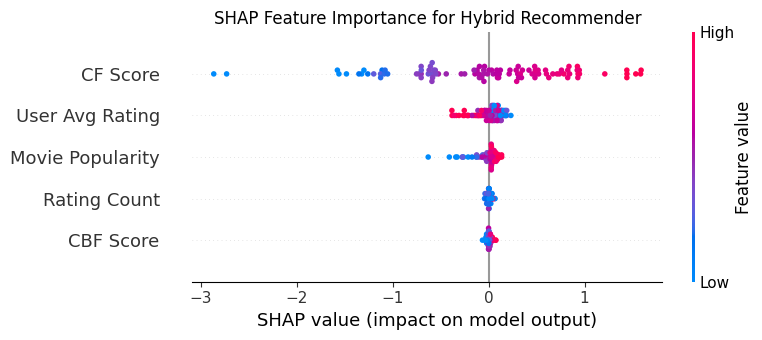


Example Explanation:
For a specific user-movie prediction:
Features: {'CBF Score': 0.364152968293699, 'CF Score': 3.6540340891872654, 'Movie Popularity': 4.219626168224299, 'User Avg Rating': 3.0840336134453783, 'Rating Count': 107.0}
Prediction: 3.96

SHAP explanation: 'This movie was recommended because...'
- CBF Score contribution: -0.009
- CF Score contribution: 0.222
- Movie Popularity contribution: 0.113
- User Avg Rating contribution: 0.154


In [45]:
#  Feature-Based Explanations using SHAP

import shap

print("Generating SHAP explanations for content-based filtering...")

explainer = shap.TreeExplainer(best_model)

X_test_sample = X_test_meta[:100]  
shap_values = explainer.shap_values(X_test_sample)

feature_names = ['CBF Score', 'CF Score', 'Movie Popularity', 'User Avg Rating', 'Rating Count']

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, feature_names=feature_names, show=False)
plt.title('SHAP Feature Importance for Hybrid Recommender')
plt.tight_layout()
plt.show()

print("\nExample Explanation:")
print("For a specific user-movie prediction:")
print(f"Features: {dict(zip(feature_names, X_test_sample[0]))}")
print(f"Prediction: {best_model.predict([X_test_sample[0]])[0]:.2f}")

print("\nSHAP explanation: 'This movie was recommended because...'")
print(f"- CBF Score contribution: {shap_values[0][0]:.3f}")
print(f"- CF Score contribution: {shap_values[0][1]:.3f}")
print(f"- Movie Popularity contribution: {shap_values[0][2]:.3f}")
print(f"- User Avg Rating contribution: {shap_values[0][3]:.3f}")

## Task 11: Neighborhood-Based Explanations (Collaborative Filtering)


In [46]:
# Neighborhood-Based Explanations for Collaborative Filtering

def explain_user_cf_recommendation(user_id, movie_id, user_movie_matrix, 
                                   user_similarity, movies_df, k=5):

    if user_id not in user_movie_matrix.index:
        return "User not found"
    
    if movie_id not in user_movie_matrix.columns:
        return "Movie not found"
    
    user_idx = user_movie_matrix.index.get_loc(user_id)
   
    similarities = user_similarity[user_idx]
    movie_ratings = user_movie_matrix[movie_id].values
  
    rated_users = []
    for i, rating in enumerate(movie_ratings):
        if not np.isnan(rating) and i != user_idx:
            rated_users.append({
                'user_id': user_movie_matrix.index[i],
                'similarity': similarities[i],
                'rating': rating
            })
   
    rated_users = sorted(rated_users, key=lambda x: x['similarity'], reverse=True)[:k]
    
    movie_info = movies_df[movies_df['movieId'] == movie_id]
    movie_title = movie_info['title'].values[0] if len(movie_info) > 0 else f"Movie {movie_id}"
    
    explanation = f"\nExplanation for recommending '{movie_title}' to User {user_id}:\n"
    explanation += "=" * 60 + "\n"
    explanation += "Similar users who also liked this movie:\n\n"
    
    for u in rated_users:
        explanation += f"  - User {u['user_id']}: "
        explanation += f"Similarity={u['similarity']:.3f}, "
        explanation += f"Rating={u['rating']:.1f}\n"
    
    explanation += "\n'Users who liked movies you like also liked this movie.'"
    
    return explanation

print("Neighborhood-Based Explanation Example:")

user_1_unrated = user_movie_matrix.loc[1][user_movie_matrix.loc[1].isna()].index[:1]
if len(user_1_unrated) > 0:
    example_movie = user_1_unrated[0]
    explanation = explain_user_cf_recommendation(1, example_movie, user_movie_matrix, 
                                                 user_similarity, movies)
    print(explanation)

Neighborhood-Based Explanation Example:

Explanation for recommending 'Jumanji (1995)' to User 1:
Similar users who also liked this movie:

  - User 414: Similarity=0.101, Rating=3.0
  - User 477: Similarity=0.099, Rating=4.0
  - User 590: Similarity=0.095, Rating=2.5
  - User 160: Similarity=0.088, Rating=4.0
  - User 226: Similarity=0.088, Rating=3.0

'Users who liked movies you like also liked this movie.'


In [47]:
# Item-based explanation

def explain_item_cf_recommendation(user_id, movie_id, user_movie_matrix, 
                                   item_similarity, movies_df, k=5):
    if user_id not in user_movie_matrix.index:
        return "User not found"
    
    if movie_id not in user_movie_matrix.columns:
        return "Movie not found"
    
    movie_idx = user_movie_matrix.columns.get_loc(movie_id)
    movie_info = movies_df[movies_df['movieId'] == movie_id]
    movie_title = movie_info['title'].values[0] if len(movie_info) > 0 else f"Movie {movie_id}"
    

    user_ratings = user_movie_matrix.loc[user_id]
    rated_movies = user_ratings[~user_ratings.isna()].index.tolist()
    
    similar_items = []
    for rated_movie in rated_movies:
        if rated_movie in user_movie_matrix.columns:
            rated_idx = user_movie_matrix.columns.get_loc(rated_movie)
            sim = item_similarity[movie_idx, rated_idx]
            user_rating = user_ratings[rated_movie]
            
            rated_info = movies_df[movies_df['movieId'] == rated_movie]
            rated_title = rated_info['title'].values[0] if len(rated_info) > 0 else f"Movie {rated_movie}"
            
            similar_items.append({
                'movie_id': rated_movie,
                'title': rated_title,
                'similarity': sim,
                'user_rating': user_rating
            })
    
    similar_items = sorted(similar_items, 
                          key=lambda x: x['similarity'] * x['user_rating'], 
                          reverse=True)[:k]
    
    explanation = f"\nExplanation for recommending '{movie_title}' to User {user_id}:\n"
    explanation += "=" * 60 + "\n"
    explanation += "Because you liked these similar movies:\n\n"
    
    for item in similar_items:
        title_short = item['title'][:40] + '...' if len(item['title']) > 40 else item['title']
        explanation += f"  - '{title_short}'\n"
        explanation += f"    Similarity={item['similarity']:.3f}, "
        explanation += f"Your rating={item['user_rating']:.1f}\n"
    
    return explanation


print("\nItem-Based Explanation Example:")
if len(user_1_unrated) > 0:
    explanation = explain_item_cf_recommendation(1, example_movie, user_movie_matrix, 
                                                 item_similarity, movies)
    print(explanation)


Item-Based Explanation Example:

Explanation for recommending 'Jumanji (1995)' to User 1:
Because you liked these similar movies:

  - 'Highlander (1986)'
    Similarity=0.240, Your rating=5.0
  - 'Mad Max (1979)'
    Similarity=0.221, Your rating=5.0
  - 'Mask, The (1994)'
    Similarity=0.258, Your rating=4.0
  - 'Back to the Future (1985)'
    Similarity=0.205, Your rating=5.0
  - 'Rushmore (1998)'
    Similarity=0.203, Your rating=5.0



## Task 12: Model-Agnostic Explainability (LIME)


In [48]:
#  LIME for Neural Network Explanations

import lime
import lime.lime_tabular

X_combined = np.hstack([X_user_nn, X_movie_nn])
feature_names_combined = [f'user_pref_{g}' for g in all_genres] + \
                        [f'movie_genre_{g}' for g in all_genres] + \
                        ['movie_year', 'movie_avg_rating']

def predict_fn(X):
    n_user_features = len(all_genres)
    X_user = X[:, :n_user_features]
    X_movie = X[:, n_user_features:]
    return model_nn.predict([X_user, X_movie], verbose=0).flatten()


print("Creating LIME explainer for Neural Network...")
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    X_combined[:1000],
    feature_names=feature_names_combined,
    mode='regression'
)

sample_idx = 0
X_sample = X_combined[sample_idx:sample_idx+1]

print("Generating LIME explanation for neural network prediction...")
exp = explainer_lime.explain_instance(
    X_sample.flatten(),
    predict_fn,
    num_features=10
)

print(f"\nLIME Explanation for prediction:")
print(f"Predicted rating: {predict_fn(X_sample)[0]:.2f}")
print(f"Actual rating: {y_nn[sample_idx]:.1f}")
print("\nTop contributing features:")
for feature, weight in exp.as_list():
    print(f"  {feature}: {weight:+.4f}")

Creating LIME explainer for Neural Network...
Generating LIME explanation for neural network prediction...

LIME Explanation for prediction:
Predicted rating: 2.88
Actual rating: 4.0

Top contributing features:
  movie_genre_Documentary <= 0.00: -0.2082
  movie_genre_Film-Noir <= 0.00: -0.1910
  movie_genre_Drama <= 0.00: -0.1452
  movie_genre_War <= 0.00: -0.1365
  user_pref_Animation > 4.33: +0.1063
  user_pref_Comedy > 4.00: +0.1034
  movie_genre_Mystery <= 0.00: -0.0990
  movie_genre_Sci-Fi <= 0.00: +0.0948
  movie_genre_Musical <= 0.00: -0.0874
  movie_genre_Crime <= 0.00: -0.0798


## Task 13: Evaluating Explainability


EVALUATION OF EXPLAINABILITY METHODS


COMPARATIVE ANALYSIS

| Aspect                  | SHAP | Neighborhood | LIME |
|------------------------|------|--------------|------|
| User Understanding     | Med  | High         | Low  |
| Technical Accuracy     | High | Med          | High |
| Bias Detection         | High | Med          | High |
| Computational Cost     | Med  | Low          | High |
| Actionable Insights    | Med  | High         | Med  |

CONCLUSION
- For end users: Neighborhood-based explanations are most intuitive
- For developers: SHAP provides best debugging insights
- For auditing: LIME reveals potential biases in complex models
- Recommendation: Use multiple methods for comprehensive understanding



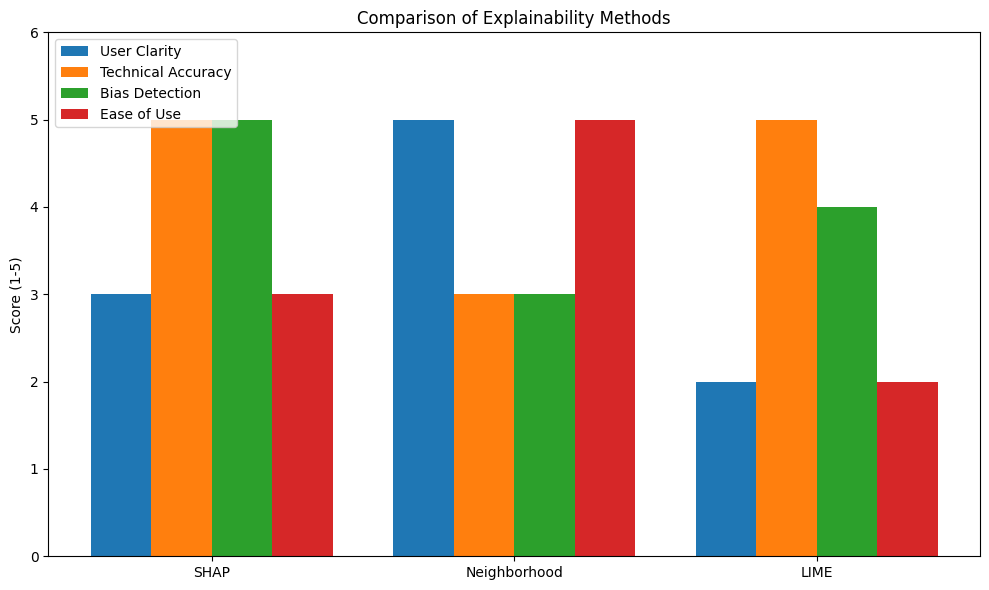

In [49]:
#  Evaluating Explainability Methods

print("=" * 70)
print("EVALUATION OF EXPLAINABILITY METHODS")
print("=" * 70)

print('''

COMPARATIVE ANALYSIS
====================

| Aspect                  | SHAP | Neighborhood | LIME |
|------------------------|------|--------------|------|
| User Understanding     | Med  | High         | Low  |
| Technical Accuracy     | High | Med          | High |
| Bias Detection         | High | Med          | High |
| Computational Cost     | Med  | Low          | High |
| Actionable Insights    | Med  | High         | Med  |

CONCLUSION
==========
- For end users: Neighborhood-based explanations are most intuitive
- For developers: SHAP provides best debugging insights
- For auditing: LIME reveals potential biases in complex models
- Recommendation: Use multiple methods for comprehensive understanding
''')

# Visualize comparison
methods = ['SHAP', 'Neighborhood', 'LIME']
metrics = {
    'User Clarity': [3, 5, 2],
    'Technical Accuracy': [5, 3, 5],
    'Bias Detection': [5, 3, 4],
    'Ease of Use': [3, 5, 2]
}

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(methods))
width = 0.2
multiplier = 0

for metric, values in metrics.items():
    offset = width * multiplier
    ax.bar(x + offset, values, width, label=metric)
    multiplier += 1

ax.set_ylabel('Score (1-5)')
ax.set_title('Comparison of Explainability Methods')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(methods)
ax.legend(loc='upper left')
ax.set_ylim(0, 6)

plt.tight_layout()
plt.show()